# IMDB Movie Review Sentiment Classification Using TensorFlow LSTM

This notebook develops a binary text-classification model that predicts whether an IMDB movie review is **positive** or **negative**.

## Workflow

1. Load and inspect the IMDB dataset
2. Check missing values, duplicates, and class distribution
3. Clean and preprocess review text
4. Encode sentiment labels
5. Split the data into training, validation, and testing sets
6. Tokenize the reviews
7. Pad sequences to a fixed length
8. Convert tokens into trainable word embeddings
9. Build and train an LSTM model
10. Evaluate the model using accuracy, precision, recall, F1-score, AUC, classification report, and confusion matrix
11. Predict sentiment for new reviews

**Dataset columns**

- `review`: movie-review text
- `sentiment`: `positive` or `negative`

The supplied notebook accepts either:

- `IMDB_Dataset.csv`
- `IMDB_Dataset_50K.zip`


## 1. Import Required Libraries

TensorFlow/Keras is used to build the neural network. Pandas handles the dataset, while scikit-learn is used for splitting and evaluation.

In [1]:
# Run this only if the required packages are not installed.
# In Google Colab, TensorFlow, pandas, matplotlib and scikit-learn are usually available.
#
# %pip install tensorflow pandas numpy matplotlib scikit-learn

import html
import os
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Set Random Seeds

Using the same seed helps make data splitting and model initialization more reproducible.

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Load the IMDB Dataset

Place either the CSV file or ZIP file in the same folder as this notebook.

When using Google Colab, upload the dataset using the **Files** panel on the left.

In [3]:
CSV_PATH = "/content/IMDB_Dataset 2.csv"
data = pd.read_csv(CSV_PATH)
print(f"Loaded dataset from: {CSV_PATH}")
print("Dataset shape:", data.shape)
data.head()

Loaded dataset from: /content/IMDB_Dataset 2.csv
Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 4. Understand the Dataset

In [4]:
print("Column names:", data.columns.tolist())
print("\nDataset information:")
data.info()

print("\nSentiment counts:")
print(data["sentiment"].value_counts())

Column names: ['review', 'sentiment']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB

Sentiment counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


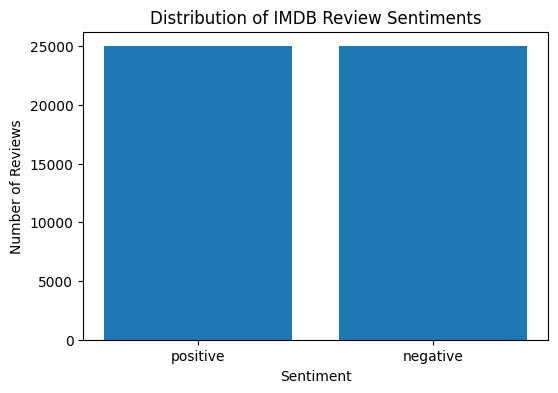

In [5]:
sentiment_counts = data["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribution of IMDB Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## 5. Check Missing Values and Duplicate Reviews

In [6]:
print("Missing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())
print(
    "Duplicate review texts:",
    data.duplicated(subset=["review"]).sum()
)

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows: 418
Duplicate review texts: 418


In [7]:
# Remove rows with missing review or sentiment values.
data = data.dropna(subset=["review", "sentiment"]).copy()

# Remove duplicate review texts to reduce data leakage.
data = data.drop_duplicates(subset=["review"]).reset_index(drop=True)

print("Shape after removing missing values and duplicates:", data.shape)
print("\nClass distribution after cleaning:")
print(data["sentiment"].value_counts())

Shape after removing missing values and duplicates: (49582, 2)

Class distribution after cleaning:
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


## 6. Text Preprocessing

The preprocessing is intentionally light because an LSTM benefits from word order and context.

The function performs the following operations:

- converts HTML entities to normal characters;
- removes HTML tags such as `<br />`;
- removes URLs;
- removes punctuation and numbers;
- converts text to lowercase;
- removes repeated spaces.

Stop-word removal and stemming are not applied because words such as **not**, **never**, and **very** can be important for sentiment.

In [8]:
def clean_review(review):
    """Clean one movie review while preserving word order."""

    review = str(review)

    # Convert entities such as &amp; into their normal characters.
    review = html.unescape(review)

    # Remove HTML tags.
    review = re.sub(r"<[^>]+>", " ", review)

    # Remove URLs.
    review = re.sub(r"https?://\S+|www\.\S+", " ", review)

    # Retain English letters and spaces.
    review = re.sub(r"[^a-zA-Z\s]", " ", review)

    # Convert to lowercase.
    review = review.lower()

    # Replace repeated whitespace with one space.
    review = re.sub(r"\s+", " ", review).strip()

    return review


example_index = 0

print("ORIGINAL REVIEW:\n")
print(data.loc[example_index, "review"][:1000])

print("\n\nCLEANED REVIEW:\n")
print(clean_review(data.loc[example_index, "review"])[:1000])

ORIGINAL REVIEW:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [9]:
# Apply preprocessing to every review.
data["cleaned_review"] = data["review"].apply(clean_review)

# Remove any rows that became empty after preprocessing.
data = data[data["cleaned_review"].str.len() > 0].reset_index(drop=True)

data[["review", "cleaned_review", "sentiment"]].head()

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...,positive


## 7. Encode Sentiment Labels

In [10]:
label_mapping = {
    "negative": 0,
    "positive": 1,
}

data["label"] = (
    data["sentiment"]
    .str.lower()
    .map(label_mapping)
)

if data["label"].isnull().any():
    invalid_labels = data.loc[data["label"].isnull(), "sentiment"].unique()
    raise ValueError(f"Unexpected sentiment labels found: {invalid_labels}")

data["label"] = data["label"].astype("int32")

data[["cleaned_review", "sentiment", "label"]].head()

,cleaned_review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production the filming tech...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there s a family where a little boy ...,negative,0
4,petter mattei s love in the time of money is a...,positive,1


## 8. Split the Dataset

The data is divided into:

- **64% training**
- **16% validation**
- **20% testing**

Stratification keeps the positive/negative proportions similar in every split.

In [11]:
X = data["cleaned_review"].astype(str).values
y = data["label"].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full,
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_validation))
print("Testing samples   :", len(X_test))

Training samples  : 31732
Validation samples: 7933
Testing samples   : 9917


## 9. Tokenize the Reviews

A tokenizer builds a vocabulary using only the training reviews and replaces each word with an integer.

`<OOV>` represents words that were not present in the selected vocabulary.

In [12]:
MAX_VOCABULARY_SIZE = 20_000
MAX_SEQUENCE_LENGTH = 250

tokenizer = Tokenizer(
    num_words=MAX_VOCABULARY_SIZE,
    oov_token="<OOV>",
)

# Learn the vocabulary from training data only.
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
validation_sequences = tokenizer.texts_to_sequences(X_validation)
test_sequences = tokenizer.texts_to_sequences(X_test)

print("Vocabulary entries learned:", len(tokenizer.word_index))
print("\nFirst 20 word-index pairs:")
print(list(tokenizer.word_index.items())[:20])

print("\nFirst review sequence before padding:")
print(train_sequences[0][:50])

Vocabulary entries learned: 82915

First 20 word-index pairs:
[('<OOV>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('it', 8), ('in', 9), ('i', 10), ('this', 11), ('that', 12), ('s', 13), ('was', 14), ('as', 15), ('movie', 16), ('for', 17), ('with', 18), ('but', 19), ('film', 20)]

First review sequence before padding:
[2320, 1275, 17863, 7, 24, 2012, 34, 90, 505, 15, 29, 5, 2, 1793, 974, 9, 347, 476, 19, 11, 20, 1695, 12, 25, 7, 470, 4, 991, 34, 403, 3261, 282, 3066, 140, 15, 4, 2917, 6, 272, 4413, 3, 31, 45, 3718, 15, 72, 15, 3170, 9347, 1749]


## 10. Pad the Sequences

Reviews have different lengths. Padding converts every review into a sequence of exactly 250 integers.

- Short reviews receive zeros at the end.
- Long reviews are truncated at the end.

In [13]:
X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

X_validation_padded = pad_sequences(
    validation_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

print("Training data shape  :", X_train_padded.shape)
print("Validation data shape:", X_validation_padded.shape)
print("Testing data shape   :", X_test_padded.shape)

print("\nFirst padded sequence:")
print(X_train_padded[0])

Training data shape  : (31732, 250)
Validation data shape: (7933, 250)
Testing data shape   : (9917, 250)

First padded sequence:
[ 2320  1275 17863     7    24  2012    34    90   505    15    29     5
     2  1793   974     9   347   476    19    11    20  1695    12    25
     7   470     4   991    34   403  3261   282  3066   140    15     4
  2917     6   272  4413     3    31    45  3718    15    72    15  3170
  9347  1749     6   116     9 16601 11427 17863   125     4  2905   291
     5  2208    11   550  2442   297     6    20     3   125     8    18
   395  7028  3853     7   409    15  2253  9348    60    46    25    51
    23  2080    98    72    25     7     2    63   276    36    96  1521
     8   122   908  2216    27  2043 13498     3  7702  1232  2614     7
     4   391  1809    15   825     3   125     4    50   291     5   114
    15  6794  7191  1415  5554     7    82    54    50    15  2523  1704
     3    43   135    18  3853     1    18    79  1212    31   728 

## 11. Understand the Embedding Layer

The input sequence contains integer word IDs. The Embedding layer learns a dense numerical vector for every word.

For example:

```text
Review sequence:       [15, 42, 108, 7, ...]
                               ↓
Embedding output:      (250 words, 128 features per word)
```

The embedding vectors are learned during model training.

In [14]:
EMBEDDING_DIMENSION = 128
LSTM_UNITS = 64

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,), name="token_sequence"),

    Embedding(
        input_dim=MAX_VOCABULARY_SIZE,
        output_dim=EMBEDDING_DIMENSION,
        mask_zero=True,
        name="word_embedding",
    ),

    LSTM(
        units=LSTM_UNITS,
        dropout=0.20,
        name="lstm_layer",
    ),

    Dense(
        units=64,
        activation="relu",
        name="dense_hidden_layer",
    ),

    Dropout(
        rate=0.40,
        name="dropout_layer",
    ),

    Dense(
        units=1,
        activation="sigmoid",
        name="sentiment_output",
    ),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word_embedding (Embedding)      │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_layer (Dense)      │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,633 (9.97 MB)

 Trainable params: 2,613,633 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

### Model Flow

```text
Cleaned review
      ↓
Tokenizer
      ↓
Padded integer sequence: (250,)
      ↓
Embedding: (250, 128)
      ↓
LSTM: (64,)
      ↓
Dense: (64,)
      ↓
Sigmoid output: probability between 0 and 1
      ↓
Negative (0) or Positive (1)
```

## 12. Inspect the Embedding Output

In [17]:
# Build a temporary model that returns the embedding layer output.
# Call the model once so Keras creates its input and output tensors.
_ = model(
    tf.convert_to_tensor(
        X_train_padded[:1],
        dtype=tf.int32
    ),
    training=False
)

# Create a model that returns the embedding-layer output.
embedding_inspector = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("word_embedding").output
)

sample_embedding = embedding_inspector.predict(
    X_train_padded[:1],
    verbose=0
)

print("Input sequence shape  :", X_train_padded[:1].shape)
print("Embedding output shape:", sample_embedding.shape)

print("\nInterpretation:")
print(
    f"1 review × {MAX_SEQUENCE_LENGTH} token positions × "
    f"{EMBEDDING_DIMENSION} embedding features"
)

Input sequence shape  : (1, 250)
Embedding output shape: (1, 250, 128)

Interpretation:
1 review × 250 token positions × 128 embedding features


## 13. Compile the LSTM Model

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

## 14. Configure Training Callbacks

- **EarlyStopping** stops training when validation loss no longer improves.
- **ReduceLROnPlateau** reduces the learning rate when learning slows.

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

reduce_learning_rate = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1,
)

## 15. Train the Model

Training the complete dataset is faster with a GPU. In Google Colab, choose:

**Runtime → Change runtime type → T4 GPU**

In [20]:
EPOCHS = 10
BATCH_SIZE = 128

history = model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_validation_padded, y_validation),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        early_stopping,
        reduce_learning_rate,
    ],
    verbose=1,
)

Epoch 1/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7674 - auc: 0.8532 - loss: 0.4766 - precision: 0.7685 - recall: 0.7677 - val_accuracy: 0.8621 - val_auc: 0.9336 - val_loss: 0.3327 - val_precision: 0.8304 - val_recall: 0.9113 - learning_rate: 0.0010
Epoch 2/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8854 - auc: 0.9501 - loss: 0.2840 - precision: 0.8900 - recall: 0.8803
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9013 - auc: 0.9586 - loss: 0.2574 - precision: 0.9035 - recall: 0.8993 - val_accuracy: 0.8652 - val_auc: 0.9400 - val_loss: 0.3650 - val_precision: 0.8208 - val_recall: 0.9357 - learning_rate: 0.0010
Epoch 3/10
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9331 - auc: 0.9769 - loss: 0.1877 - precision: 0.9293 - recall: 0.9381
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accu

## 16. Plot Training History

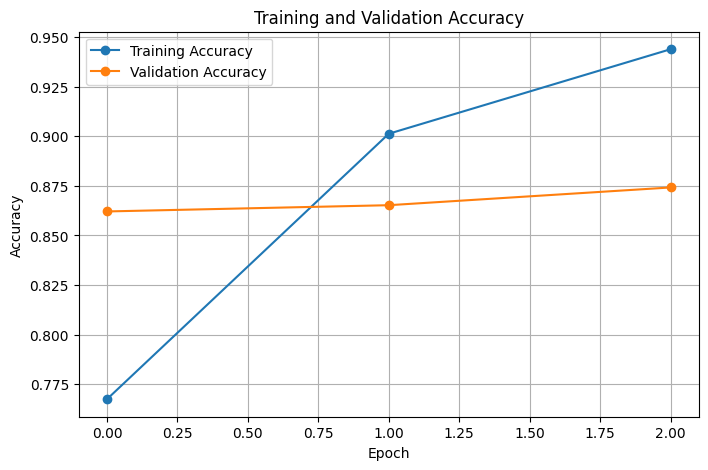

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

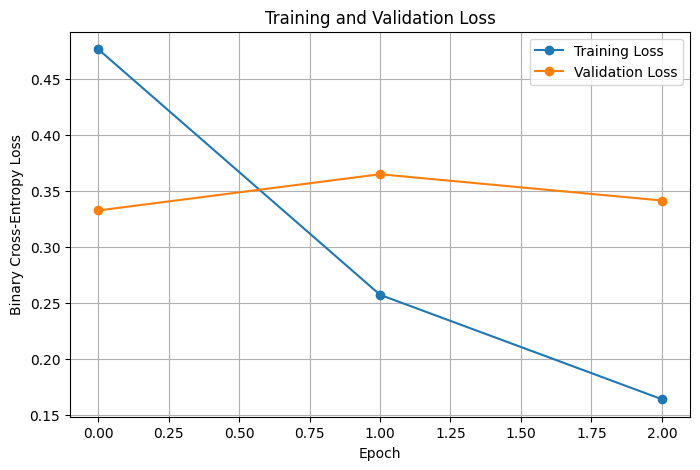

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()

## 17. Evaluate the Model on Unseen Test Data

In [23]:
evaluation_results = model.evaluate(
    X_test_padded,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=1,
    return_dict=True,
)

print("\nTest Evaluation Results")
print("-" * 35)

for metric_name, metric_value in evaluation_results.items():
    print(f"{metric_name:10s}: {metric_value:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8671 - auc: 0.9389 - loss: 0.3208 - precision: 0.8356 - recall: 0.9152

Test Evaluation Results
-----------------------------------
accuracy  : 0.8671
auc       : 0.9389
loss      : 0.3208
precision : 0.8356
recall    : 0.9152


## 18. Generate Test Predictions

In [24]:
predicted_probabilities = model.predict(
    X_test_padded,
    batch_size=BATCH_SIZE,
    verbose=1,
).reshape(-1)

predicted_labels = (predicted_probabilities >= 0.5).astype("int32")

print("First 10 probabilities:", predicted_probabilities[:10])
print("First 10 predictions  :", predicted_labels[:10])
print("First 10 actual labels:", y_test[:10])

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
First 10 probabilities: [0.02351926 0.95296115 0.887837   0.08948311 0.07400982 0.9233766
 0.02910158 0.1031148  0.96342546 0.01668883]
First 10 predictions  : [0 1 1 0 0 1 0 0 1 0]
First 10 actual labels: [0 1 1 0 0 1 0 0 1 0]


## 19. Calculate Accuracy, Precision, Recall, F1-Score, and AUC

In [25]:
test_accuracy = accuracy_score(y_test, predicted_labels)
test_precision = precision_score(y_test, predicted_labels, zero_division=0)
test_recall = recall_score(y_test, predicted_labels, zero_division=0)
test_f1 = f1_score(y_test, predicted_labels, zero_division=0)
test_auc = roc_auc_score(y_test, predicted_probabilities)

print("Final Test Metrics")
print("-" * 25)
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

Final Test Metrics
-------------------------
Accuracy : 0.8671
Precision: 0.8356
Recall   : 0.9152
F1-score : 0.8736
ROC-AUC  : 0.9389


## 20. Classification Report

In [26]:
print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=["Negative", "Positive"],
        digits=4,
    )
)

              precision    recall  f1-score   support

    Negative     0.9055    0.8186    0.8599      4940
    Positive     0.8356    0.9152    0.8736      4977

    accuracy                         0.8671      9917
   macro avg     0.8706    0.8669    0.8667      9917
weighted avg     0.8704    0.8671    0.8668      9917



## 21. Confusion Matrix

Confusion matrix:
[[4044  896]
 [ 422 4555]]


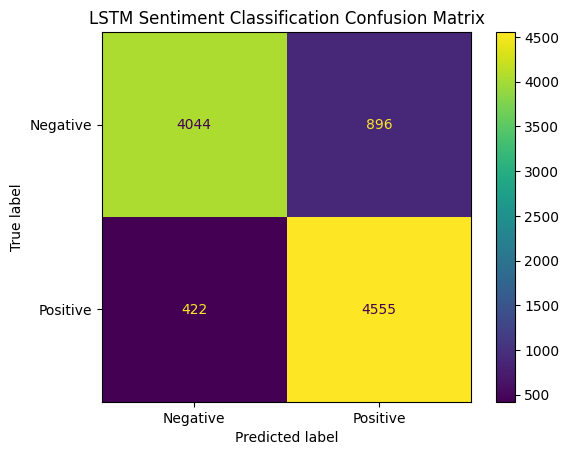

In [27]:
matrix = confusion_matrix(y_test, predicted_labels)

print("Confusion matrix:")
print(matrix)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["Negative", "Positive"],
).plot(values_format="d")

plt.title("LSTM Sentiment Classification Confusion Matrix")
plt.show()

### Confusion-Matrix Interpretation

```text
                    Predicted
                Negative  Positive

Actual Negative     TN       FP
Actual Positive     FN       TP
```

- **TN:** negative review correctly classified
- **FP:** negative review incorrectly classified as positive
- **FN:** positive review incorrectly classified as negative
- **TP:** positive review correctly classified

## 22. Display Sample Test Predictions

In [28]:
NUMBER_OF_SAMPLES = 10

for index in range(NUMBER_OF_SAMPLES):
    actual_sentiment = "Positive" if y_test[index] == 1 else "Negative"
    predicted_sentiment = (
        "Positive" if predicted_labels[index] == 1 else "Negative"
    )

    print("=" * 80)
    print("REVIEW:")
    print(X_test[index][:500] + "...")
    print("\nActual sentiment   :", actual_sentiment)
    print("Predicted sentiment:", predicted_sentiment)
    print(
        "Positive probability:",
        f"{predicted_probabilities[index]:.4f}",
    )

REVIEW:
my wife and i watched this after dvr ing it off of encore action this past week it has to be the worst horror flick either of us had ever seen predictable dialogue my wife and i were guessing the lines before they were spoken hokey special effects a screenplay that drifted all over the place i think the part that was the most annoying was the stereotyping of the various characters in the plot not to mention the gratuitous sex scene between two of the young heroines in the movie neither of which ...

Actual sentiment   : Negative
Predicted sentiment: Negative
Positive probability: 0.0235
REVIEW:
i was surprised how much i enjoyed this sure it is a bit slow moving in parts but what else would one expect from rollin also there is plenty of nudity nothing wrong with that particularly as it includes lots of the gorgeous brigitte lahaie there are also some spectacularly eroticised female dead bit more dodgey perhaps but most effective there is also a sci fi like storyline with a brie

## 23. Predict the Sentiment of a New Review

In [29]:
def predict_sentiment(review):
    """Clean, tokenize, pad, and classify a new movie review."""

    cleaned_text = clean_review(review)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post",
    )

    positive_probability = float(
        model.predict(padded_sequence, verbose=0)[0][0]
    )

    if positive_probability >= 0.5:
        predicted_sentiment = "Positive"
        confidence = positive_probability
    else:
        predicted_sentiment = "Negative"
        confidence = 1.0 - positive_probability

    print("Review:", review)
    print("Cleaned review:", cleaned_text)
    print("Predicted sentiment:", predicted_sentiment)
    print(f"Confidence: {confidence * 100:.2f}%")
    print(f"Positive probability: {positive_probability:.4f}")

    return predicted_sentiment, positive_probability

In [30]:
positive_review = (
    "The movie was excellent. The story was interesting, "
    "the actors were brilliant, and I enjoyed every scene."
)

negative_review = (
    "The movie was boring and disappointing. "
    "The story was confusing and the acting was terrible."
)

predict_sentiment(positive_review)

print("\n" + "=" * 80 + "\n")

predict_sentiment(negative_review)

Review: The movie was excellent. The story was interesting, the actors were brilliant, and I enjoyed every scene.
Cleaned review: the movie was excellent the story was interesting the actors were brilliant and i enjoyed every scene
Predicted sentiment: Positive
Confidence: 86.00%
Positive probability: 0.8600


Review: The movie was boring and disappointing. The story was confusing and the acting was terrible.
Cleaned review: the movie was boring and disappointing the story was confusing and the acting was terrible
Predicted sentiment: Negative
Confidence: 97.19%
Positive probability: 0.0281


('Negative', 0.028088603168725967)

## 24. Save the Model and Tokenizer

In [31]:
import json

model.save("imdb_lstm_sentiment_model.keras")

tokenizer_json = tokenizer.to_json()

with open("imdb_tokenizer.json", "w", encoding="utf-8") as file:
    file.write(tokenizer_json)

print("Model saved as: imdb_lstm_sentiment_model.keras")
print("Tokenizer saved as: imdb_tokenizer.json")

Model saved as: imdb_lstm_sentiment_model.keras
Tokenizer saved as: imdb_tokenizer.json


## Summary

In this notebook, you:

- cleaned raw movie-review text;
- encoded positive and negative labels;
- tokenized the reviews;
- padded variable-length sequences;
- learned word embeddings;
- built an LSTM sentiment classifier;
- trained the model with validation monitoring;
- evaluated it using multiple classification metrics;
- predicted the sentiment of new reviews.

# 25. Deploy the Saved LSTM Model as a Classroom Web Application

The model-training, evaluation, prediction, and saving sections above remain unchanged.  
This final section creates a small browser-based application using **Gradio**.

## Classroom use

1. Show the selected film to the class.
2. Ask one student at a time to give an oral comment.
3. Enter the comment in the web application.
4. Click **Add Review**.
5. The application immediately displays:
   - whether the review is positive or negative;
   - the model confidence;
   - an individual review-derived score out of 10;
   - the updated overall movie score;
   - the complete list of reviews entered so far.

This is an educational **sentiment-derived movie score**, not the official IMDb rating.

## 26. Install and Import Gradio

Run this cell in Google Colab after completing the model-training and model-saving cells.

In [32]:
# Install Gradio for the browser-based user interface.
%pip install -q "gradio>=5,<7"

In [33]:
import os
import threading
from datetime import datetime

import gradio as gr
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

print("Gradio version:", gr.__version__)

Gradio version: 6.19.0


## 27. Load the Saved Model and Tokenizer When Required

When all previous notebook cells have been executed, the variables `model` and `tokenizer` already exist.

The following cell also supports deployment after a runtime restart by loading:

- `imdb_lstm_sentiment_model.keras`
- `imdb_tokenizer.json`

In [34]:
MODEL_FILE = "imdb_lstm_sentiment_model.keras"
TOKENIZER_FILE = "imdb_tokenizer.json"

# Use the sequence length already defined during training.
if "MAX_SEQUENCE_LENGTH" not in globals():
    MAX_SEQUENCE_LENGTH = 250

# Load the saved model only when the current runtime does not contain it.
if "model" not in globals():
    if not os.path.exists(MODEL_FILE):
        raise FileNotFoundError(
            f"{MODEL_FILE} was not found. Run the model-saving cell first."
        )

    model = tf.keras.models.load_model(MODEL_FILE)
    print("Saved LSTM model loaded.")

# Load the saved tokenizer only when the current runtime does not contain it.
if "tokenizer" not in globals():
    if not os.path.exists(TOKENIZER_FILE):
        raise FileNotFoundError(
            f"{TOKENIZER_FILE} was not found. Run the tokenizer-saving cell first."
        )

    with open(TOKENIZER_FILE, "r", encoding="utf-8") as file:
        tokenizer = tokenizer_from_json(file.read())

    print("Saved tokenizer loaded.")

if "clean_review" not in globals():
    raise RuntimeError(
        "The clean_review() preprocessing function is unavailable. "
        "Run the preprocessing cells above before launching the application."
    )

print("Deployment components are ready.")

Deployment components are ready.


## 28. Movie and Score Configuration

The sample classroom film is **3 Idiots (2009)**. You can replace the title and description below with another suitable film.

### Score calculation

For every review, the LSTM generates a positive probability \(p\), from 0 to 1.

\[
\text{Review Score} = 1 + 9p
\]

Examples:

| Positive probability | Review-derived score |
|---:|---:|
| 0.00 | 1.0/10 |
| 0.25 | 3.25/10 |
| 0.50 | 5.5/10 |
| 0.75 | 7.75/10 |
| 1.00 | 10.0/10 |

After each review is added:

\[
\text{Current Movie Score}
=
\frac{\text{Sum of all review scores}}
{\text{Number of reviews}}
\]

Therefore, every new review immediately changes the movie score.

In [35]:
# Change these values to use another film.

FILM_TITLE = "3 Idiots"
FILM_YEAR = "2009"

FILM_DESCRIPTION = (
    "Three engineering students experience friendship, academic pressure, "
    "creativity, competition, and different ideas about success."
)

REVIEW_QUESTION = (
    "What did you think about the story, acting, characters, music, "
    "message, or overall experience of this film?"
)

print(f"Selected film: {FILM_TITLE} ({FILM_YEAR})")

Selected film: 3 Idiots (2009)


## 29. Sentiment Prediction and Movie-Score Logic

In [36]:
def predict_review_for_app(review_text):
    """
    Preprocess one review and return sentiment information.

    Returns:
        sentiment
        confidence
        positive_probability
        negative_probability
        review_score
    """

    cleaned_text = clean_review(review_text)

    if len(cleaned_text.split()) < 3:
        raise ValueError(
            "Enter a meaningful review containing at least three words."
        )

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post",
    )

    positive_probability = float(
        model.predict(
            padded_sequence,
            verbose=0,
        )[0][0]
    )

    negative_probability = 1.0 - positive_probability

    if positive_probability >= 0.5:
        sentiment = "Positive"
        confidence = positive_probability
    else:
        sentiment = "Negative"
        confidence = negative_probability

    # Map a probability from 0-1 to a score from 1-10.
    review_score = 1.0 + (9.0 * positive_probability)

    return {
        "sentiment": sentiment,
        "confidence": confidence,
        "positive_probability": positive_probability,
        "negative_probability": negative_probability,
        "review_score": round(review_score, 2),
    }

## 30. Store Reviews Entered by the Teacher

The responses are stored in memory for the current Colab runtime.  
Each click on **Add Review** creates one new record.

In [37]:
review_records = []
review_lock = threading.Lock()


def reviews_dataframe():
    """Return all entered reviews as a display-friendly table."""

    columns = [
        "Review No.",
        "Review",
        "Sentiment",
        "Review Score",
        "Positive Probability",
        "Confidence",
        "Added At",
    ]

    if not review_records:
        return pd.DataFrame(columns=columns)

    return pd.DataFrame(review_records, columns=columns)


def calculate_running_movie_score():
    """Calculate the mean of all individual review-derived scores."""

    if not review_records:
        return None

    scores = [
        record["Review Score"]
        for record in review_records
    ]

    return float(np.mean(scores))

## 31. Create Individual and Overall Result Cards

In [38]:
def individual_result_html(result, review_number):
    """Create the result displayed after one review is submitted."""

    sentiment = result["sentiment"]
    confidence = result["confidence"]
    positive_probability = result["positive_probability"]
    negative_probability = result["negative_probability"]
    review_score = result["review_score"]

    if sentiment == "Positive":
        card_class = "positive-card"
        icon = "😊"
    else:
        card_class = "negative-card"
        icon = "☹️"

    return f"""
    <div class="result-card {card_class}">
        <div class="result-icon">{icon}</div>
        <div>
            <h2>Review {review_number}: {sentiment}</h2>
            <p>
                <strong>Review-derived movie score:</strong>
                {review_score:.1f}/10
            </p>
            <p>
                <strong>Model confidence:</strong>
                {confidence * 100:.1f}%
            </p>
            <p>
                Positive probability: {positive_probability * 100:.1f}%
                &nbsp; | &nbsp;
                Negative probability: {negative_probability * 100:.1f}%
            </p>
        </div>
    </div>
    """


def movie_score_html():
    """Create the continuously updated overall movie-score card."""

    review_count = len(review_records)

    if review_count == 0:
        return """
        <div class="movie-score-card">
            <div class="score-title">Current Movie Score</div>
            <div class="large-score">--<span>/10</span></div>
            <div>No reviews have been added.</div>
        </div>
        """

    movie_score = calculate_running_movie_score()

    positive_count = sum(
        record["Sentiment"] == "Positive"
        for record in review_records
    )

    negative_count = review_count - positive_count

    return f"""
    <div class="movie-score-card">
        <div class="score-title">Current Sentiment-Derived Movie Score</div>
        <div class="large-score">
            {movie_score:.1f}<span>/10</span>
        </div>
        <div class="score-stats">
            <span><strong>{review_count}</strong> reviews</span>
            <span><strong>{positive_count}</strong> positive</span>
            <span><strong>{negative_count}</strong> negative</span>
        </div>
        <div class="score-note">
            Updated after every review. This is not the official IMDb rating.
        </div>
    </div>
    """

## 32. Add, Reset, and Export Review Functions

In [39]:
def add_review(review_text):
    """Classify one review, add it, and update the movie score."""

    review_text = str(review_text).strip()

    if not review_text:
        raise gr.Error("Enter the student's oral review before clicking Add Review.")

    if len(review_text) > 1500:
        raise gr.Error("Please keep the review within 1,500 characters.")

    try:
        result = predict_review_for_app(review_text)
    except ValueError as error:
        raise gr.Error(str(error)) from error

    with review_lock:
        review_number = len(review_records) + 1

        review_records.append({
            "Review No.": review_number,
            "Review": review_text,
            "Sentiment": result["sentiment"],
            "Review Score": result["review_score"],
            "Positive Probability": (
                f'{result["positive_probability"] * 100:.1f}%'
            ),
            "Confidence": f'{result["confidence"] * 100:.1f}%',
            "Added At": datetime.now().strftime("%H:%M:%S"),
        })

        result_card = individual_result_html(
            result,
            review_number,
        )

        overall_score_card = movie_score_html()
        review_table = reviews_dataframe()

    # The final empty string clears the input box for the next oral review.
    return (
        result_card,
        overall_score_card,
        review_table,
        "",
    )


def reset_all_reviews():
    """Clear all reviews and begin the activity again."""

    with review_lock:
        review_records.clear()

    return (
        "",
        movie_score_html(),
        reviews_dataframe(),
        "",
    )


def export_reviews_to_csv():
    """Export the current reviews and score to a CSV file."""

    with review_lock:
        if not review_records:
            raise gr.Error("There are no reviews to export.")

        export_data = reviews_dataframe().copy()
        current_score = calculate_running_movie_score()

        export_data["Current Overall Movie Score"] = round(
            current_score,
            2,
        )

        safe_title = "".join(
            character
            if character.isalnum()
            else "_"
            for character in FILM_TITLE
        ).strip("_")

        export_path = f"{safe_title}_class_reviews.csv"

        export_data.to_csv(
            export_path,
            index=False,
        )

    return export_path

## 33. Build the Browser-Based Gradio Application

In [40]:
APP_CSS = """
.gradio-container {
    max-width: 1120px !important;
    margin: auto !important;
}

.film-card {
    border-radius: 20px;
    padding: 28px;
    background: linear-gradient(135deg, #171b2d, #323a62);
    color: white;
    margin-bottom: 16px;
}

.film-card h1 {
    margin: 0 0 5px 0;
    font-size: 34px;
}

.film-card h2 {
    margin: 0 0 14px 0;
    font-weight: 500;
}

.question-card {
    border: 1px solid #d8dce8;
    border-radius: 16px;
    padding: 18px;
    margin-bottom: 18px;
}

.result-card {
    border-radius: 18px;
    padding: 20px;
    display: flex;
    gap: 18px;
    align-items: flex-start;
    margin-top: 14px;
}

.result-icon {
    font-size: 42px;
}

.result-card h2 {
    margin-top: 0;
}

.positive-card {
    background: #eaf8ef;
    border: 1px solid #69b780;
}

.negative-card {
    background: #fff0f0;
    border: 1px solid #d67b7b;
}

.movie-score-card {
    border-radius: 20px;
    padding: 24px;
    background: #111522;
    color: white;
    text-align: center;
}

.score-title {
    font-size: 20px;
    font-weight: 700;
}

.large-score {
    font-size: 66px;
    line-height: 1.15;
    font-weight: 800;
}

.large-score span {
    font-size: 25px;
    font-weight: 500;
}

.score-stats {
    display: flex;
    flex-wrap: wrap;
    justify-content: center;
    gap: 22px;
    margin-top: 10px;
}

.score-note {
    margin-top: 15px;
    font-size: 13px;
    opacity: 0.78;
}
"""


with gr.Blocks(
    title=f"{FILM_TITLE} Classroom Sentiment",
    css=APP_CSS,
) as movie_review_app:

    gr.HTML(
        f"""
        <div class="film-card">
            <h1>🎬 Classroom Movie Review</h1>
            <h2>{FILM_TITLE} ({FILM_YEAR})</h2>
            <p>{FILM_DESCRIPTION}</p>
        </div>
        """
    )

    gr.HTML(
        f"""
        <div class="question-card">
            <strong>Ask the student orally:</strong><br>
            {REVIEW_QUESTION}
            <br><br>
            Enter the student's answer below and click
            <strong>Add Review</strong>.
        </div>
        """
    )

    with gr.Row():
        with gr.Column(scale=6):
            review_input = gr.Textbox(
                label="Enter the Student's Oral Review",
                placeholder=(
                    "Example: The film was inspiring and entertaining. "
                    "I liked its message about learning and friendship."
                ),
                lines=6,
                max_lines=10,
            )

            with gr.Row():
                add_review_button = gr.Button(
                    "Add Review",
                    variant="primary",
                )

                reset_button = gr.Button(
                    "Reset All Reviews",
                    variant="secondary",
                )

        with gr.Column(scale=4):
            movie_score_output = gr.HTML(
                value=movie_score_html()
            )

    individual_result_output = gr.HTML()

    gr.Markdown("## Reviews Added So Far")

    review_table_output = gr.Dataframe(
        value=reviews_dataframe(),
        headers=[
            "Review No.",
            "Review",
            "Sentiment",
            "Review Score",
            "Positive Probability",
            "Confidence",
            "Added At",
        ],
        datatype=[
            "number",
            "str",
            "str",
            "number",
            "str",
            "str",
            "str",
        ],
        interactive=False,
        wrap=True,
    )

    gr.Markdown("## Export the Classroom Results")

    export_button = gr.Button(
        "Prepare CSV File",
    )

    export_file_output = gr.File(
        label="Download Reviews and Movie Score",
    )

    gr.Markdown(
        """
        **Note:** The score is derived from the LSTM model's sentiment
        probability. It is intended for a classroom demonstration and is not
        the official IMDb rating of the film. Sarcasm, very short reviews,
        neutral comments, and mixed-language reviews may be misclassified.
        """
    )

    add_review_button.click(
        fn=add_review,
        inputs=review_input,
        outputs=[
            individual_result_output,
            movie_score_output,
            review_table_output,
            review_input,
        ],
    )

    reset_button.click(
        fn=reset_all_reviews,
        inputs=None,
        outputs=[
            individual_result_output,
            movie_score_output,
            review_table_output,
            review_input,
        ],
    )

    export_button.click(
        fn=export_reviews_to_csv,
        inputs=None,
        outputs=export_file_output,
    )

## 34. Launch the Application in Google Colab

Run this cell after executing all previous cells.

Gradio displays the application inside Colab and creates a temporary public browser link.  
Keep the Colab runtime active while using the application.

In [41]:
movie_review_app.queue().launch(
    share=True,
    debug=False,
    show_error=True,
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5417101787829e9c58.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 35. Expected Application Behaviour

For every oral student comment:

1. Enter the comment.
2. Click **Add Review**.
3. The app reports **Positive** or **Negative** sentiment.
4. It displays that review's model confidence and score out of 10.
5. The review is added to the table.
6. The overall movie score is recalculated immediately.
7. The input box is cleared for the next review.

Use **Reset All Reviews** before starting another class or another film.